# **Experiment 3: Diff Model**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os


In [3]:
save_path = '/content/drive/MyDrive/Diffusion_results'
os.makedirs(save_path, exist_ok=True)

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('using:', device)

using: cuda


In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)


100%|██████████| 170M/170M [00:03<00:00, 47.5MB/s]


In [6]:
# noise scheduler
T = 1000  # total timesteps
beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

def get_noisy_image(x0, t):
    # q(x_t | x_0) from DDPM eq 4
    a = alphas_cumprod[t].view(-1, 1, 1, 1)
    noise = torch.randn_like(x0)
    x_t = torch.sqrt(a) * x0 + torch.sqrt(1 - a) * noise
    return x_t, noise

In [9]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, time_emb_dim=64):
        super(UNet, self).__init__()

        # time embedding
        self.time_mlp = nn.Sequential(
            nn.Linear(1, time_emb_dim),
            nn.ReLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )

        # encoder
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)

        self.pool = nn.MaxPool2d(2)

        # bottleneck
        self.bottleneck = DoubleConv(256, 512)

        # fix: t_proj output must match bottleneck channels = 512
        self.t_proj = nn.Linear(time_emb_dim, 512)

        # decoder
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.out_conv = nn.Conv2d(64, in_channels, 1)

    def forward(self, x, t):
        # time embedding
        t = t.float().unsqueeze(-1) / T
        t_emb = self.time_mlp(t)                         # (B, time_emb_dim)
        t_out = self.t_proj(t_emb).unsqueeze(-1).unsqueeze(-1)  # (B, 512, 1, 1)

        # encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        # bottleneck + add time
        b = self.bottleneck(self.pool(e3))   # (B, 512, H, W)
        b = b + t_out                         # broadcast works now

        # decoder
        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)

In [10]:
#training
model = UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-4)
criterion = nn.MSELoss()

num_params = sum(p.numel() for p in model.parameters())
print(f'unet params: {num_params:,}')

num_epochs = 50
losses = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        B = imgs.shape[0]

        # random timestep for each image in batch
        t = torch.randint(0, T, (B,)).to(device)

        x_t, noise = get_noisy_image(imgs, t)

        optimizer.zero_grad()
        pred_noise = model(x_t, t)
        loss = criterion(pred_noise, noise)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)
    print(f'Epoch {epoch+1}/{num_epochs}  loss: {avg_loss:.5f}')


torch.save(model.state_dict(), os.path.join(save_path, 'diffusion_model.pth'))

#38 min


unet params: 7,740,675
Epoch 1/50  loss: 0.09386
Epoch 2/50  loss: 0.05438
Epoch 3/50  loss: 0.04896
Epoch 4/50  loss: 0.04503
Epoch 5/50  loss: 0.04379
Epoch 6/50  loss: 0.04231
Epoch 7/50  loss: 0.04091
Epoch 8/50  loss: 0.04029
Epoch 9/50  loss: 0.03971
Epoch 10/50  loss: 0.03873
Epoch 11/50  loss: 0.03826
Epoch 12/50  loss: 0.03818
Epoch 13/50  loss: 0.03722
Epoch 14/50  loss: 0.03725
Epoch 15/50  loss: 0.03717
Epoch 16/50  loss: 0.03687
Epoch 17/50  loss: 0.03697
Epoch 18/50  loss: 0.03568
Epoch 19/50  loss: 0.03617
Epoch 20/50  loss: 0.03628
Epoch 21/50  loss: 0.03597
Epoch 22/50  loss: 0.03542
Epoch 23/50  loss: 0.03555
Epoch 24/50  loss: 0.03566
Epoch 25/50  loss: 0.03544
Epoch 26/50  loss: 0.03523
Epoch 27/50  loss: 0.03527
Epoch 28/50  loss: 0.03501
Epoch 29/50  loss: 0.03502
Epoch 30/50  loss: 0.03534
Epoch 31/50  loss: 0.03460
Epoch 32/50  loss: 0.03464
Epoch 33/50  loss: 0.03450
Epoch 34/50  loss: 0.03495
Epoch 35/50  loss: 0.03398
Epoch 36/50  loss: 0.03432
Epoch 37/50  l

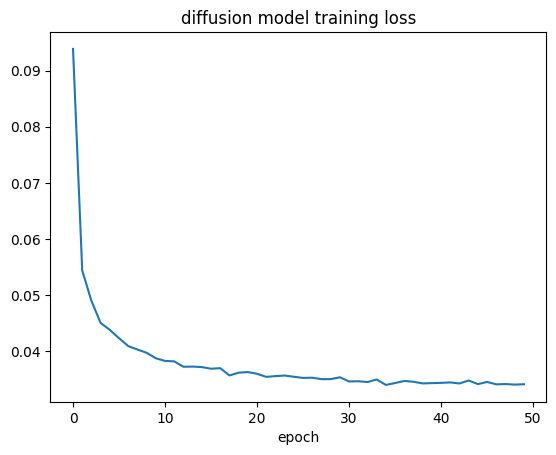

In [11]:
plt.plot(losses)
plt.title('diffusion model training loss')
plt.xlabel('epoch')
plt.savefig(os.path.join(save_path, 'training_curve.png'))
plt.show()

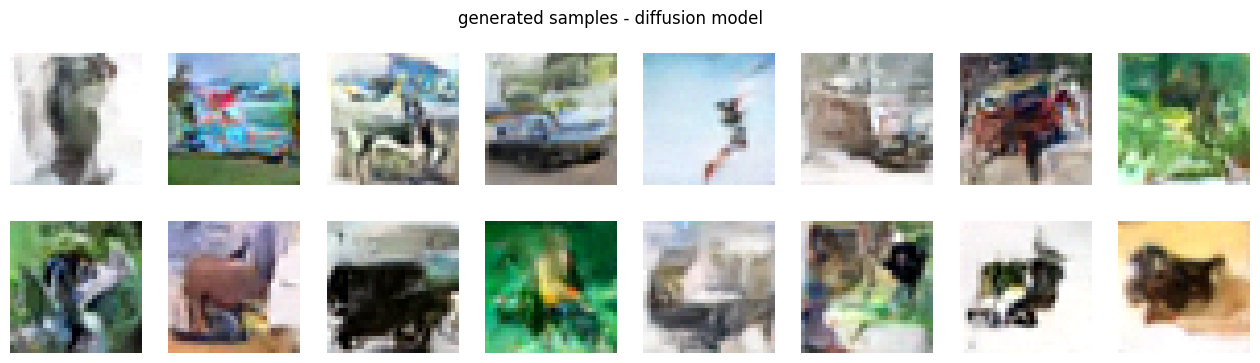

In [12]:
# reverse denoising
@torch.no_grad()
def sample(model, n_samples=16):
    model.eval()
    x = torch.randn(n_samples, 3, 32, 32).to(device)

    for t_step in reversed(range(T)):
        t_tensor = torch.full((n_samples,), t_step, dtype=torch.long).to(device)

        pred_noise = model(x, t_tensor)

        alpha = alphas[t_step]
        alpha_hat = alphas_cumprod[t_step]
        beta = betas[t_step]

        if t_step > 0:
            z = torch.randn_like(x)
        else:
            z = 0

        # denoising step from DDPM eq 11
        x = (1 / torch.sqrt(alpha)) * (x - (1 - alpha) / torch.sqrt(1 - alpha_hat) * pred_noise)
        x = x + torch.sqrt(beta) * z

    return x


samples = sample(model, 16)
samples = (samples.clamp(-1, 1) + 1) / 2  # to [0,1]

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i].cpu().permute(1, 2, 0).numpy())
    ax.axis('off')

plt.suptitle('generated samples - diffusion model')
plt.savefig(os.path.join(save_path, 'generated_samples.png'))
plt.show()

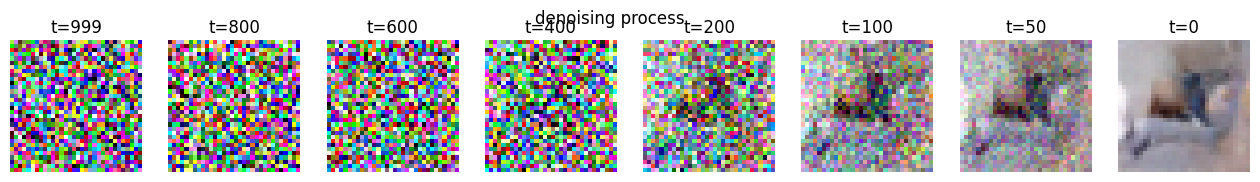

all done! check drive folder


In [13]:
@torch.no_grad()
def show_denoising_steps(model):
    model.eval()
    x = torch.randn(1, 3, 32, 32).to(device)
    snapshots = []
    steps_to_show = [999, 800, 600, 400, 200, 100, 50, 0]
    steps_to_show_set = set(steps_to_show)

    for t_step in reversed(range(T)):
        t_tensor = torch.full((1,), t_step, dtype=torch.long).to(device)
        pred_noise = model(x, t_tensor)

        alpha = alphas[t_step]
        alpha_hat = alphas_cumprod[t_step]
        beta = betas[t_step]

        z = torch.randn_like(x) if t_step > 0 else 0
        x = (1 / torch.sqrt(alpha)) * (x - (1 - alpha) / torch.sqrt(1 - alpha_hat) * pred_noise)
        x = x + torch.sqrt(beta) * z

        if t_step in steps_to_show_set:
            img = (x.clamp(-1, 1) + 1) / 2
            snapshots.append((t_step, img[0].cpu().permute(1, 2, 0).numpy()))

    return snapshots


snapshots = show_denoising_steps(model)

fig, axes = plt.subplots(1, len(snapshots), figsize=(16, 2))
for i, (step, img) in enumerate(snapshots):
    axes[i].imshow(img)
    axes[i].set_title(f't={step}')
    axes[i].axis('off')

plt.suptitle('denoising process')
plt.savefig(os.path.join(save_path, 'denoising_visualization.png'))
plt.show()

print('all done! check drive folder')